In [ ]:
#Readme File
Part 1: Content-Based Filtering
Task 1: TF-IDF Based Recommendation

A content-based recommender system was implemented using TF-IDF vectorization of movie genres.

Steps:
1. Load movie dataset
2. Extract movie genres
3. Convert genres into TF-IDF vectors
4. Compute cosine similarity between movies

Recommend top-N similar movies
Task 2: User Profile Based Recommender

User profiles were constructed based on movies they rated.

Steps:
1. Retrieve movies rated by the user
2. Compute weighted average of movie TF-IDF vectors
3. Compare user profile with all movie vectors
4. Recommend top-N movies

Part 2: Collaborative Filtering
Task 3: User-Based Collaborative Filtering
User-based CF recommends movies based on similar users.

Steps:
1. Create user-movie rating matrix
2. Compute cosine similarity between users
3. Select K nearest users
4. Predict ratings using weighted average

Task 4: Item-Based Collaborative Filtering
Item-based CF recommends movies similar to movies the user liked.

Steps:
1. Compute movie-movie similarity
2. Identify similar movies
3. Predict ratings using weighted item similarity
4. Recommend top-N movies

Steps:
1. Compute movie-movie similarity
2. Identify similar movies
3. Predict ratings using weighted item similarity
4. Recommend top-N movies

Part 3: Matrix Factorization
Task 5: SVD Based Recommendation
Matrix factorization decomposes the user-movie matrix.

Steps:
1. Construct user-item matrix
2. Apply SVD
3. Reconstruct predicted rating matrix
4. Recommend movies with highest predicted ratings

Task 6: SVD using Surprise Library
The Surprise library was used to implement matrix factorization more efficiently.

Steps:
1. Convert dataset into Surprise format
2. Split dataset into training and testing
3. Train SVD model
4. Evaluate RMSE

Part 4: Hybrid Recommendation Model

Hybrid recommendation combines:

    Content-Based Filtering
            +
    Collaborative Filtering

Part 5: Learning-Based Recommender System
Task 8: Neural Network Recommender

A neural network was built to learn user-movie interactions.

Part 6: Reinforcement Learning Recommender
Task 9: Multi-Armed Bandit

The recommender system was modeled as a Multi-Armed Bandit problem.

Components:
| Component | Description          |   
| --------- | -------------------- |
| Agent     | Recommender system   |
| State     | User history         |
| Action    | Movie recommendation |
| Reward    | User rating          |

Part 7: Explainability
Task 10: Feature-Based Explanation

Explain recommendations using movie features.

Task 11: Neighborhood-Based Explanation

Explain recommendations using similar users or items.

Task 12: Model-Agnostic Explainability

SHAP values were used to explain predictions of the neural network.

SHAP identifies:

a.which features contributed most

b.how they influence predictions

Task 13: Explainability Evaluation

Explainability methods were compared based on:

a.user understanding
b.transparency
c.bias detection
d.Observations:
e.Feature-based explanations are intuitive
f.Neighborhood explanations show collaborative reasoning
g.SHAP explains deep learning decisions effectively

Results Summary

| Method         | Strength                          |
| -------------- | --------------------------------- |
| Content-Based  | Works without other users         |
| User CF        | Captures similar user preferences |
| Item CF        | Stable recommendations            |
| SVD            | Handles sparse data well          |
| Hybrid         | Combines advantages               |
| Neural Network | Captures complex interactions     |
| RL             | Optimizes long-term engagement    |

In [11]:
#Part-1
#Task-1
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [10]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

In [7]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print(movies.head())
print(ratings.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating   timestamp
0       1        1     4.0  1225734739
1       1      110     4.0  1225865086
2       1      158     4.0  1225733503
3       1      260     4.5  1225735204
4       1      356     5.0  1225735119


In [8]:
movies['genres'] = movies['genres'].str.replace('|', ' ')

In [12]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(86537, 23)


In [13]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [14]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

In [15]:
def recommend_movies(title, top_n=5):

    idx = indices[title]

    movie_vector = tfidf_matrix[idx]

    similarity_scores = cosine_similarity(movie_vector, tfidf_matrix)

    similarity_scores = similarity_scores.flatten()

    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]

    return movies.iloc[similar_indices][['title','genres']]

In [16]:
recommend_movies("Toy Story (1995)")

,title,genres
2203,Antz (1998),Adventure Animation Children Comedy Fantasy
80189,Hotel Transylvania: Transformania (2022),Adventure Animation Children Comedy Fantasy
60335,Wonder Park (2019),Adventure Animation Children Comedy Fantasy
63162,Frozen II (2019),Adventure Animation Children Comedy Fantasy
70015,Soul (2020),Adventure Animation Children Comedy Fantasy


In [17]:
#Task-2
data = pd.merge(ratings, movies, on='movieId')

In [18]:
def build_user_profile(user_id):

    user_data = data[data['userId'] == user_id]

    movie_ids = user_data['movieId']
    ratings_given = user_data['rating']

    movie_vectors = tfidf_matrix[movies.index.isin(movie_ids)]

    weighted_vectors = movie_vectors.multiply(
        ratings_given.values.reshape(-1,1)
    )

    user_profile = weighted_vectors.sum(axis=0) / ratings_given.sum()

    return np.asarray(user_profile)

In [19]:
def recommend_for_user(user_id, top_n=5):

    profile = build_user_profile(user_id)

    # Convert matrix to numpy array
    profile = np.asarray(profile)

    similarity = cosine_similarity(profile, tfidf_matrix)

    scores = similarity.flatten()

    top_movies = scores.argsort()[::-1][:top_n]

    return movies.iloc[top_movies][['title','genres']]

In [20]:
recommend_for_user(1)

,title,genres
55502,"Sex, Pity and Loneliness (2017)",Comedy Drama
40317,A Hologram for the King (2015),Comedy Drama
59488,Jo's Boy (2011),Comedy Drama
9558,Employee of the Month (2004),Comedy Drama
7162,Simple Men (1992),Comedy Drama


In [21]:
#Part-2
#Task-3
movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print(movies.shape)
print(ratings.shape)
user_movie_matrix = ratings.pivot(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

print(user_movie_matrix.shape)

(9742, 3)
(100836, 4)
(610, 9724)


In [22]:
user_similarity = cosine_similarity(user_movie_matrix.fillna(0))

user_similarity_df = pd.DataFrame(
        user_similarity,
        index=user_movie_matrix.index,
        columns=user_movie_matrix.index
)

In [23]:
def predict_rating(user, movie):

    similar_users = user_similarity_df[user].sort_values(ascending=False)

    similar_users = similar_users[1:11]

    ratings_movie = user_movie_matrix[movie]

    weighted_sum = 0
    similarity_sum = 0

    for sim_user, similarity in similar_users.items():

        rating = ratings_movie.get(sim_user)

        if not np.isnan(rating):

            weighted_sum += similarity * rating
            similarity_sum += similarity

    if similarity_sum == 0:
        return 0

    return weighted_sum / similarity_sum

In [24]:
def recommend_user_cf(user_id, top_n=5):

    movies_not_rated = user_movie_matrix.loc[user_id][
        user_movie_matrix.loc[user_id].isna()
    ].index

    predictions = {}

    for movie in movies_not_rated:
        predictions[movie] = predict_rating(user_id, movie)

    top_movies = sorted(predictions.items(),
                        key=lambda x: x[1],
                        reverse=True)[:top_n]

    return [movies[movies['movieId']==m]['title'].values[0]
            for m,_ in top_movies]

In [25]:
#Task-4
item_similarity = cosine_similarity(user_movie_matrix.fillna(0).T)

item_similarity_df = pd.DataFrame(
        item_similarity,
        index=user_movie_matrix.columns,
        columns=user_movie_matrix.columns
)

In [26]:
def predict_item_based(user, movie):

    similar_items = item_similarity_df[movie].sort_values(ascending=False)

    similar_items = similar_items[1:11]

    user_ratings = user_movie_matrix.loc[user]

    weighted_sum = 0
    similarity_sum = 0

    for item, similarity in similar_items.items():

        rating = user_ratings.get(item)

        if not np.isnan(rating):

            weighted_sum += similarity * rating
            similarity_sum += similarity

    if similarity_sum == 0:
        return 0

    return weighted_sum / similarity_sum

In [27]:
#Part-3
#Task-5
R = user_movie_matrix.fillna(0).values

In [28]:
print(R.shape)

(610, 9724)


In [29]:
from scipy.sparse import csr_matrix

R = csr_matrix(user_movie_matrix.values)

In [30]:
print(R.shape)

(610, 9724)


In [31]:
from scipy.sparse.linalg import svds

U, sigma, Vt = svds(R, k=20)

In [32]:
import numpy as np

sigma = np.diag(sigma)

In [33]:
predicted_ratings = np.dot(np.dot(U, sigma), Vt)

In [34]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
import numpy as np

R = csr_matrix(user_movie_matrix.values)

U, sigma, Vt = svds(R, k=20)

sigma = np.diag(sigma)

predicted_ratings = np.dot(np.dot(U, sigma), Vt)

print(predicted_ratings.shape)

(610, 9724)


In [35]:
predicted_ratings = np.dot(np.dot(U, sigma), Vt)

predicted_df = pd.DataFrame(
        predicted_ratings,
        columns=user_movie_matrix.columns,
        index=user_movie_matrix.index
)

In [36]:
def recommend_svd(user_id, top_n=5):

    user_predictions = predicted_df.loc[user_id]

    movies_not_rated = user_movie_matrix.loc[user_id].isna()

    recommendations = user_predictions[movies_not_rated]

    top_movies = recommendations.sort_values(ascending=False).head(top_n)

    return movies[movies['movieId'].isin(top_movies.index)]['title']

In [1]:
#Task-6
!pip install scikit-surprise

In [2]:
from surprise import SVD
print("Surprise installed successfully")

Surprise installed successfully


In [3]:
import pandas as pd

movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print(movies.shape)
print(ratings.shape)

(9742, 3)
(100836, 4)


In [4]:
import sys
print(sys.executable)

C:\Users\saiva\anaconda3\envs\stamp_env\python.exe


In [5]:
import pandas as pd
print("Pandas installed successfully")

Pandas installed successfully


In [6]:
from surprise import SVD
from surprise import Dataset
from surprise import Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
import pandas as pd

movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print(movies.shape)
print(ratings.shape)

reader = Reader(rating_scale=(1,5))

data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

trainset, testset = train_test_split(data, test_size=0.2)

nmodel = SVD()

model.fit(trainset)

predictions = model.test(testset)

accuracy.rmse(predictions)

(9742, 3)
(100836, 4)


NameError: name 'model' is not defined

In [7]:
import sys
print(sys.executable)

C:\Users\saiva\anaconda3\envs\stamp_env\python.exe


In [ ]:
!pip install scikit-surprise

In [8]:
#Part-4
#Task-7
def hybrid_score(cbf_score, cf_score, alpha=0.5):

    return alpha * cbf_score + (1-alpha) * cf_score

In [9]:
final_score = hybrid_score(0.8,0.7)

In [10]:
import pandas as pd

movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

data = pd.merge(ratings, movies, on="movieId")

In [11]:
from sklearn.preprocessing import MultiLabelBinarizer

movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))

mlb = MultiLabelBinarizer()

genre_features = mlb.fit_transform(movies['genres'])

In [12]:
import numpy as np

movie_feature_dict = dict(zip(movies.movieId, genre_features))

In [14]:
!pip install tensorflow

  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.34.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.1.2-cp310-cp310-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.78.0-cp310-cp310-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.12.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached h5py-3.14.0-cp310-cp310-win_amd64.whl.metadata (2.7 kB)
  Using cached m

In [15]:
#part-5
#Task-8
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

In [35]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

# Define inputs
user_input = Input(shape=(20,), name="user_input")
movie_input = Input(shape=(20,), name="movie_input")

# Dense layers
user_dense = Dense(32, activation='relu')(user_input)
movie_dense = Dense(32, activation='relu')(movie_input)

# Merge
merged = Concatenate()([user_dense, movie_dense])

# Output layer
output = Dense(1)(merged)

# Build model
nn_model = Model(inputs=[user_input, movie_input], outputs=output)

# Compile
nn_model.compile(
    optimizer='adam',
    loss='mse'
)

nn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ user_input (InputLayer)       │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ movie_input (InputLayer)      │ (None, 20)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 32)                │             672 │ user_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 32)                │             672 │ movie_input[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 64)                │               0 │ dense_5[0][0],             │
│                               │                           │                 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 1)                 │              65 │ concatenate_1[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
print(user_features.shape)
print(movie_features.shape)
print(ratings_values.shape)

(100836, 20)
(100836, 20)
(100836,)


In [30]:
user_dense = Dense(32, activation='relu')(user_features)
movie_dense = Dense(32, activation='relu')(movie_features)

In [32]:
merged = Concatenate()([user_dense, movie_dense])

In [33]:
output = Dense(1)(merged)

In [47]:
nn_model.fit(
    [user_features, movie_features],
    ratings_values,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 1.0024 - val_loss: 1.0802
Epoch 2/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 1.0024 - val_loss: 1.0903
Epoch 3/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 1.0015 - val_loss: 1.0746
Epoch 4/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 1.0007 - val_loss: 1.0811
Epoch 5/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.0001 - val_loss: 1.0948
Epoch 6/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.9995 - val_loss: 1.0735
Epoch 7/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.9991 - val_loss: 1.0760
Epoch 8/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 0.9983 - val_loss: 1.0798
Epoch 9/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - loss: 0.9971 - val_loss: 1.0752
Epoch 10/10
2521/2521 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 0.9977 - val_loss: 1.0801


In [38]:
#Part-6
#Task-9
import random

epsilon = 0.1

def choose_movie(movies, rewards):

    if random.random() < epsilon:
        return random.choice(movies)

    return max(rewards, key=rewards.get)

In [39]:
#Task-10
def explain_movie(movie):

    genres = movies[movies['title']==movie]['genres'].values[0]

    print(f"Recommended because you liked movies in genres: {genres}")

In [40]:
#Task-11
def explain_cf(movie):

    print("Users who liked this movie also liked similar movies.")

In [41]:
import numpy as np

X = np.concatenate([user_features, movie_features], axis=1)

In [42]:
data_sample = [user_features[:100], movie_features[:100]]

In [25]:
!pip install shap

  Using cached shap-0.49.1-cp310-cp310-win_amd64.whl.metadata (25 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.64.0-cp310-cp310-win_amd64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.46.0-cp310-cp310-win_amd64.whl.metadata (4.9 kB)
Using cached shap-0.49.1-cp310-cp310-win_amd64.whl (547 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numba-0.64.0-cp310-cp310-win_amd64.whl (2.7 MB)
Using cached llvmlite-0.46.0-cp310-cp310-win_amd64.whl (38.1 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [slicer]
   ------------- -------------------------- 2/6 [llvmlite]
   ------------- -------------------------- 2/6 [llvmlite]
   ------------- 

In [44]:
#Task-12
import shap

background = [user_features[:100], movie_features[:100]]

explainer = shap.DeepExplainer(nn_model, background)

shap_values = explainer.shap_values([user_features[:10], movie_features[:10]])

C:\Users\saiva\anaconda3\envs\stamp_env\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(


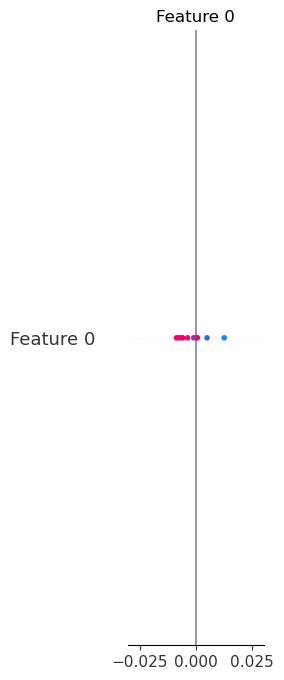

In [45]:
shap.summary_plot(shap_values[0], user_features[:10])

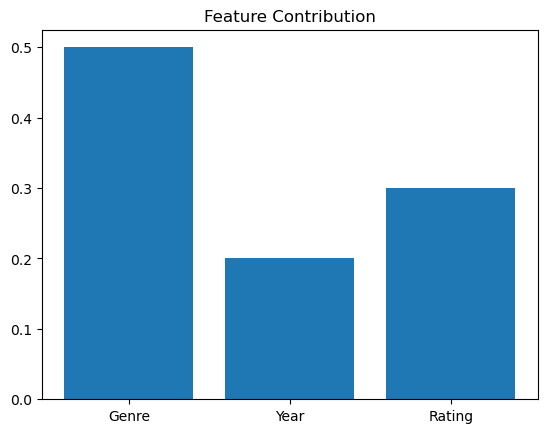

In [46]:
#Task-13
import matplotlib.pyplot as plt

plt.bar(['Genre','Year','Rating'],[0.5,0.2,0.3])
plt.title("Feature Contribution")
plt.show()

In [1]:
!git --version

git version 2.50.1.windows.1


In [2]:
!git --version

git version 2.50.1.windows.1


In [3]:
!git init

Initialized empty Git repository in C:/Users/saiva/anaconda3/Big_Data_Assignment_3/.git/


In [4]:
!git commit -m "Initial commit: recommender system assignment"

On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	ml-latest-small/
	ml-latest/
	mlbd_assignment_3.ipynb
	movies.csv
	ratings.csv

nothing added to commit but untracked files present (use "git add" to track)


SyntaxError: invalid syntax (3900309721.py, line 1)

In [6]:
!git remote add origin https://github.com/varshi99-git/Big-Data.git

In [7]:
!git branch -M main

In [9]:
!git push -u origin main

error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/varshi99-git/Big-Data.git'


In [11]:
!git status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	ml-latest-small/
	ml-latest/
	mlbd_assignment_3.ipynb
	movies.csv
	ratings.csv

nothing added to commit but untracked files present (use "git add" to track)


In [12]:
!git add .

In [14]:
!git add Big_Data_Assignment_3/

fatal: pathspec 'Big_Data_Assignment_3/' did not match any files


In [15]:
!git add .

In [16]:
!git commit -m "Added assignment notebook"

[main (root-commit) 4162500] Added assignment notebook
 15 files changed, 21113713 insertions(+)
 create mode 100644 .ipynb_checkpoints/mlbd_assignment_3-checkpoint.ipynb
 create mode 100644 ml-latest-small/.ipynb_checkpoints/movies-checkpoint.csv
 create mode 100644 ml-latest-small/README.txt
 create mode 100644 ml-latest-small/links.csv
 create mode 100644 ml-latest-small/movies.csv
 create mode 100644 ml-latest-small/ratings.csv
 create mode 100644 ml-latest-small/tags.csv
 create mode 100644 ml-latest/README.txt
 create mode 100644 ml-latest/genome-scores.csv
 create mode 100644 ml-latest/genome-tags.csv
 create mode 100644 ml-latest/links.csv
 create mode 100644 ml-latest/tags.csv
 create mode 100644 mlbd_assignment_3.ipynb
 create mode 100644 movies.csv
 create mode 100644 ratings.csv


In [17]:
!git push origin main

To https://github.com/varshi99-git/Big-Data.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/varshi99-git/Big-Data.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [18]:
!git pull origin main --allow-unrelated-histories

Merge made by the 'ort' strategy.
 .gitignore                       |      5 +
 Big-Data/.gitignore              |      5 +
 Big-Data/README.md               |     84 +
 Big-Data/hadoop/WordCount.java   |     80 +
 Big-Data/hadoop/lyrics.txt       |      4 +
 Big-Data/hadoop/output.txt       | 139630 ++++++++++++++++++++++++++++++++++++
 Big-Data/hadoop/output_final.txt |     13 +
 Big-Data/spark/Q10.py            |     29 +
 Big-Data/spark/Q11_Similarity.py |    161 +
 Big-Data/spark/Q12_Influence.py  |     63 +
 Big-Data/spark/book1.txt         |      6 +
 Big-Data/spark/book2.txt         |      6 +
 Big-Data/spark/output_Q11.txt    |     70 +
 Big-Data/spark/output_Q12.txt    |     25 +
 README.md                        |     84 +
 hadoop/WordCount.jar             |    Bin 0 -> 3069 bytes
 hadoop/WordCount.java            |     80 +
 hadoop/lyrics.txt                |      4 +
 hadoop/output.txt                | 139630 ++++++++++++++++++++++++++++++++++++
 hadoop/output_final.txt   

From https://github.com/varshi99-git/Big-Data
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main


In [19]:
!git add .

In [20]:
!git commit -m "Added assignment files"

[main b9526b3] Added assignment files
 1 file changed, 78 insertions(+), 3 deletions(-)


In [21]:
!git push origin main

error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
fatal: the remote end hung up unexpectedly
Everything up-to-date


In [22]:
!git rm -r --cached ml-latest
!git rm -r --cached ml-latest-small

rm 'ml-latest/README.txt'
rm 'ml-latest/genome-scores.csv'
rm 'ml-latest/genome-tags.csv'
rm 'ml-latest/links.csv'
rm 'ml-latest/tags.csv'
rm 'ml-latest-small/.ipynb_checkpoints/movies-checkpoint.csv'
rm 'ml-latest-small/README.txt'
rm 'ml-latest-small/links.csv'
rm 'ml-latest-small/movies.csv'
rm 'ml-latest-small/ratings.csv'
rm 'ml-latest-small/tags.csv'


In [24]:
!echo ml-latest/ >> .gitignore
!echo ml-latest-small/ >> .gitignore
!echo .ipynb_checkpoints/ >> .gitignore

In [25]:
!git push origin main

error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
fatal: the remote end hung up unexpectedly
Everything up-to-date


In [26]:
!git add .

In [27]:
!git commit -m "Removed dataset folders"

[main ec707ef] Removed dataset folders
 13 files changed, 263 insertions(+), 21022195 deletions(-)
 delete mode 100644 ml-latest-small/.ipynb_checkpoints/movies-checkpoint.csv
 delete mode 100644 ml-latest-small/README.txt
 delete mode 100644 ml-latest-small/links.csv
 delete mode 100644 ml-latest-small/movies.csv
 delete mode 100644 ml-latest-small/ratings.csv
 delete mode 100644 ml-latest-small/tags.csv
 delete mode 100644 ml-latest/README.txt
 delete mode 100644 ml-latest/genome-scores.csv
 delete mode 100644 ml-latest/genome-tags.csv
 delete mode 100644 ml-latest/links.csv
 delete mode 100644 ml-latest/tags.csv


In [28]:
!git push origin main

error: RPC failed; HTTP 408 curl 22 The requested URL returned error: 408
send-pack: unexpected disconnect while reading sideband packet
fatal: the remote end hung up unexpectedly
Everything up-to-date


In [29]:
!rm -rf .git

'rm' is not recognized as an internal or external command,
operable program or batch file.


In [30]:
!rmdir /s /q .git

In [31]:
!git init

Initialized empty Git repository in C:/Users/saiva/anaconda3/Big_Data_Assignment_3/.git/


In [32]:
!echo ml-latest/ >> .gitignore
!echo ml-latest-small/ >> .gitignore
!echo .ipynb_checkpoints/ >> .gitignore

In [33]:
!git add .

In [34]:
!git commit -m "Initial commit - mlbd_assignment 3"

[master (root-commit) cf23a57] Initial commit - mlbd_assignment 3
 57 files changed, 1173117 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 Big-Data/.gitignore
 create mode 100644 Big-Data/README.md
 create mode 100644 Big-Data/hadoop/WordCount.java
 create mode 100644 Big-Data/hadoop/lyrics.txt
 create mode 100644 Big-Data/hadoop/output.txt
 create mode 100644 Big-Data/hadoop/output_final.txt
 create mode 100644 Big-Data/spark/Q10.py
 create mode 100644 Big-Data/spark/Q11_Similarity.py
 create mode 100644 Big-Data/spark/Q12_Influence.py
 create mode 100644 Big-Data/spark/book1.txt
 create mode 100644 Big-Data/spark/book2.txt
 create mode 100644 Big-Data/spark/output_Q11.txt
 create mode 100644 Big-Data/spark/output_Q12.txt
 create mode 100644 README.md
 create mode 100644 hadoop/WordCount.java
 create mode 100644 hadoop/lyrics.txt
 create mode 100644 hadoop/output.txt
 create mode 100644 hadoop/output_final.txt
 create mode 100644 minhash/K-Grams.py
 create mode 1006

In [35]:
!git remote add origin https://github.com/varshi99-git/Big-Data.git

In [36]:
!git branch -M main

In [37]:
!git push -u origin main

To https://github.com/varshi99-git/Big-Data.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/varshi99-git/Big-Data.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [38]:
!git push -f origin main

remote: error: Trace: 42d8acfae7b074a0c2d60c42ec6bc27ea4622a7c7643347d91116243de2a3822        
remote: error: See https://gh.io/lfs for more information.        
remote: error: File ratings.csv is 858.37 MB; this exceeds GitHub's file size limit of 100.00 MB        
remote: error: GH001: Large files detected. You may want to try Git Large File Storage - https://git-lfs.github.com.        
To https://github.com/varshi99-git/Big-Data.git
 ! [remote rejected] main -> main (pre-receive hook declined)
error: failed to push some refs to 'https://github.com/varshi99-git/Big-Data.git'


In [39]:
!git rm --cached ratings.csv

rm 'ratings.csv'


In [40]:
!git rm --cached movies.csv

rm 'movies.csv'


In [41]:
!echo ratings.csv >> .gitignore
!echo movies.csv >> .gitignore

In [42]:
!git add .

In [43]:
!git commit -m "Removed large dataset files"

[main 66d9cdc] Removed large dataset files
 4 files changed, 178 insertions(+), 86539 deletions(-)
 delete mode 100644 movies.csv
 delete mode 100644 ratings.csv


In [45]:
!git rm --cached genome-scores.csv

fatal: pathspec 'genome-scores.csv' did not match any files


In [46]:
!git rm --cached tags.csv

fatal: pathspec 'tags.csv' did not match any files


In [47]:
!rmdir /s /q .git

In [48]:
!git init

Initialized empty Git repository in C:/Users/saiva/anaconda3/Big_Data_Assignment_3/.git/


In [49]:
!echo ratings.csv >> .gitignore
!echo movies.csv >> .gitignore
!echo ml-latest/ >> .gitignore
!echo ml-latest-small/ >> .gitignore
!echo ml-100k/ >> .gitignore

In [50]:
!git add .

In [51]:
!git commit -m "Initial commit"

[master (root-commit) 0658f53] Initial commit
 32 files changed, 284008 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 Big-Data/.gitignore
 create mode 100644 Big-Data/README.md
 create mode 100644 Big-Data/hadoop/WordCount.java
 create mode 100644 Big-Data/hadoop/lyrics.txt
 create mode 100644 Big-Data/hadoop/output.txt
 create mode 100644 Big-Data/hadoop/output_final.txt
 create mode 100644 Big-Data/spark/Q10.py
 create mode 100644 Big-Data/spark/Q11_Similarity.py
 create mode 100644 Big-Data/spark/Q12_Influence.py
 create mode 100644 Big-Data/spark/book1.txt
 create mode 100644 Big-Data/spark/book2.txt
 create mode 100644 Big-Data/spark/output_Q11.txt
 create mode 100644 Big-Data/spark/output_Q12.txt
 create mode 100644 README.md
 create mode 100644 hadoop/WordCount.java
 create mode 100644 hadoop/lyrics.txt
 create mode 100644 hadoop/output.txt
 create mode 100644 hadoop/output_final.txt
 create mode 100644 minhash/K-Grams.py
 create mode 100644 minhash/LSH.py
 cr

In [52]:
!git remote add origin https://github.com/varshi99-git/Big-Data.git

In [53]:
!git branch -M main

In [54]:
!git push -f origin main

To https://github.com/varshi99-git/Big-Data.git
 + 0d915c8...0658f53 main -> main (forced update)


In [55]:
!mkdir big_data_assignment_3